In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io

# Load signal
data = scipy.io.loadmat('Signals_task2/Signal3.mat')
r = data['R'].flatten()

# System parameters
fs = 44100
fc = 4000
N  = 100
Ns = len(r) // N

# Pulse shape
p = np.sin(np.pi * np.arange(N) / N)

# Carrier waves
n     = np.arange(Ns * N)
cos_c = np.cos(2 * np.pi * fc * n / fs)
sin_c = np.sin(2 * np.pi * fc * n / fs)

**DOWNCONVERSION**

In [18]:
n_full = np.arange(len(r))
r_I =  2 * r * np.cos(2 * np.pi * fc * n_full / fs)
r_Q = -2 * r * np.sin(2 * np.pi * fc * n_full / fs)

**SYNC**

In [19]:
# Synchronization: cross-correlate r with known pilot passband waveform
# Pilot symbol (2+2j): passband = p[n]*(2*cos(2pi*fc*n/fs) - 2*sin(2pi*fc*n/fs))
n_p = np.arange(N)
p_pulse = np.sin(np.pi * n_p / N)
r_bb = r_I + 1j * r_Q

pilot_bb = p_pulse * (2 - 2j)

abs_corr = np.abs(np.correlate(r_bb, pilot_bb, mode='valid'))

# First pilot peak
# Can't assume first peak is first in time
peak1 = np.argmax(abs_corr)

search = abs_corr.copy()
search[max(0, peak1 - N) : peak1 + N] = 0
peak2 = np.argmax(search)

tau_start = min(peak1, peak2)
tau_end   = max(peak1, peak2)

Ns_packet = (tau_end - tau_start) // N + 1
print(f'Pilot 1 at sample {tau_start}, Pilot 2 at sample {tau_end}')
print(f'Packet symbols (incl. pilots): {Ns_packet}')


Pilot 1 at sample 132641, Pilot 2 at sample 161828
Packet symbols (incl. pilots): 292


**CHANNEL ESTIMATION**

In [20]:
yI = r_I[tau_start : tau_start + Ns_packet*N].reshape(Ns_packet, N) @ p
yQ = r_Q[tau_start : tau_start + Ns_packet*N].reshape(Ns_packet, N) @ p
y  = yI + 1j * yQ

h_start  = y[0]  / (2 + 2j)
h_end    = y[-1] / (2 + 2j)
k        = np.arange(Ns_packet)
h_interp = h_start + (h_end - h_start) * k / (Ns_packet - 1)

print(f'h_start = {h_start:.3f}')
print(f'h_end   = {h_end:.3f}')


h_start = 16249.228-15731.178j
h_end   = 8564.260-14629.021j


**PILOT REMOVAL**

In [21]:
y_data = y[1:-1]
h_data = h_interp[1:-1]

**SAMPLING AND CHANNEL EQUALIZATION**

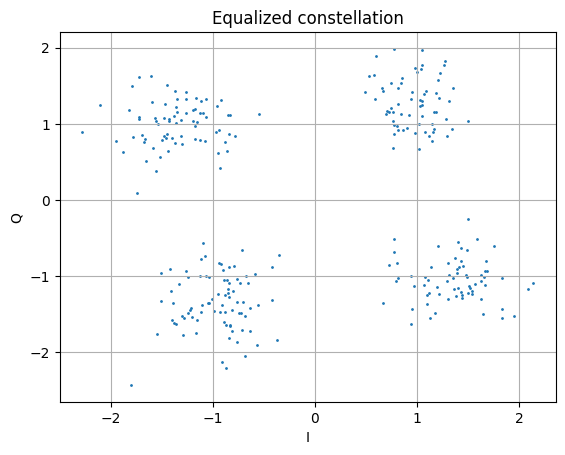

In [22]:
y_eq = y_data / h_data

plt.scatter(y_eq.real, y_eq.imag, s=1)
plt.xlabel('I'); plt.ylabel('Q')
plt.title('Equalized constellation')
plt.grid(); plt.show()

**DECODING**

In [23]:
bits = []
for sym in y_eq:
    bits.append('1' if sym.real < 0 else '0')
    bits.append('1' if sym.imag < 0 else '0')

bitstr = ''.join(bits)
n_bits  = (len(bitstr) // 7) * 7
message = ''.join(chr(int(bitstr[j:j+7], 2)) for j in range(0, n_bits, 7))
print(f'Message: {message}')

Message: Shannon's 1948/1949 papers are by far the most famous papers of information theory


**ANSWER** 
Final message is Turbo Codes were invented by Berrou, Glavieux and Thi4imajshima 1993 or Turbo Codes were invented by Berrou, Glavieux and Thitimajshima 1993 